<a href="https://colab.research.google.com/github/Arzuyasar/amazon-customer-review/blob/main/Faz_2_%E2%80%94_Temizleme_%26_Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q pyarrow plotly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, gc
from IPython.display import display

from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/'
print("Hazır")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Hazır


In [3]:
print("Veri yükleniyor...")
df = pd.read_parquet(DRIVE_PATH + 'faz1_ham_veri.parquet')
print(f"{len(df):,} satır, {df.shape[1]} sütun yüklendi")
print(f" RAM: {df.memory_usage(deep=True).sum()/1024**2:.0f} MB")
df.head(3)

Veri yükleniyor...
300,000 satır, 13 sütun yüklendi
 RAM: 239 MB


,review_id,product_id,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date,kaynak
0,RTIS3L2M1F5SM,B001CXYMFS,Thrustmaster T-Flight Hotas X Flight Stick,Video Games,5,0,0,N,Y,an amazing joystick. I especially love that yo...,"Used this for Elite Dangerous on my mac, an am...",2015-08-31,Video_Games
1,R1ZV7R40OLHKD,B00M920ND6,Tonsee 6 buttons Wireless Optical Silent Gamin...,Video Games,5,0,0,N,Y,Definitely a silent mouse... Not a single clic...,"Loved it, I didn't even realise it was a gami...",2015-08-31,Video_Games
2,R3BH071QLH8QMC,B0029CSOD2,Hidden Mysteries: Titanic Secrets of the Fatef...,Video Games,1,0,1,N,Y,One Star,poor quality work and not as it is advertised.,2015-08-31,Video_Games


In [4]:
def temizle(df):
    baslangic = len(df)

    df['review_body'] = (
        df['review_body']
        .astype(str)
        .str.strip()
        .str.replace(r'\s+', ' ', regex=True)
        .str.replace(r'<[^>]+>', '', regex=True)
    )

    masks = {
        'boş_yorum':  df['review_body'].isin(['', 'nan', 'None', 'N/A']),
        'çok_kısa':   df['review_body'].str.len() < 20,
        'çok_uzun':   df['review_body'].str.len() > 10_000,
        'eksik_puan': df['star_rating'].isna(),
        'duplicate':  df.duplicated(subset=['product_id', 'review_body'], keep='first'),
    }

    print("── Temizleme Raporu ──────────────────────────")
    for sebep, mask in masks.items():
        print(f"  {sebep:<20}  {mask.sum():>8,} satır elendi")

    kotu_satirlar = pd.concat(
        [v.rename(k) for k, v in masks.items()], axis=1
    ).any(axis=1)

    df = df[~kotu_satirlar].copy()

    print(f"  {'─'*38}")
    print(f"  {'Başlangıç':<20}  {baslangic:>8,}")
    print(f"  {'Kalan':<20}  {len(df):>8,}")
    print(f"  {'Oran':<20}  %{len(df)/baslangic*100:>7.1f} kaldı")
    return df

df = temizle(df)
gc.collect()
print("\nTemizleme tamamlandı")

── Temizleme Raporu ──────────────────────────
  boş_yorum                   53 satır elendi
  çok_kısa                42,470 satır elendi
  çok_uzun                   102 satır elendi
  eksik_puan                   2 satır elendi
  duplicate                  963 satır elendi
  ──────────────────────────────────────
  Başlangıç              300,000
  Kalan                  257,378
  Oran                  %   85.8 kaldı

Temizleme tamamlandı


In [5]:
df['review_date']   = pd.to_datetime(df['review_date'], errors='coerce')

df['helpful_votes'] = df['helpful_votes'].fillna(0).astype(int)
df['total_votes']   = df['total_votes'].fillna(0).astype(int)
df['star_rating']   = df['star_rating'].astype('Int8')

print("Güncel veri tipleri:")
print(df.dtypes.to_string())

Güncel veri tipleri:
review_id                    object
product_id                   object
product_title                object
product_category             object
star_rating                    Int8
helpful_votes                 int64
total_votes                   int64
vine                       category
verified_purchase          category
review_headline              object
review_body                  object
review_date          datetime64[ns]
kaynak                       object


In [6]:
def wilson_score(helpful: pd.Series, total: pd.Series, z: float = 1.96) -> pd.Series:

    total_safe = total.replace(0, np.nan)
    p          = helpful / total_safe
    denom      = 1 + z**2 / total_safe
    center     = p + z**2 / (2 * total_safe)
    spread     = z * np.sqrt(p*(1-p)/total_safe + z**2/(4*total_safe**2))
    score      = (center - spread) / denom
    return score.fillna(0)

df['helpfulness_score'] = wilson_score(df['helpful_votes'], df['total_votes'])

df['helpfulness_score'] = df['helpfulness_score'].where(
    df['total_votes'] >= 5, other=np.nan
)

print("Wilson skoru istatistikleri:")
print(df['helpfulness_score'].describe().round(3).to_string())

print("\nÖrnek karşılaştırma:")
print(f"  1/1   ham oran: %100.0  →  Wilson: %{wilson_score(pd.Series([1]), pd.Series([1])).iloc[0]*100:.1f}")
print(f"  95/100 ham oran: %95.0  →  Wilson: %{wilson_score(pd.Series([95]), pd.Series([100])).iloc[0]*100:.1f}")

Wilson skoru istatistikleri:
count    14708.000
mean         0.431
std          0.256
min         -0.000
25%          0.231
50%          0.453
75%          0.627
max          0.976

Örnek karşılaştırma:
  1/1   ham oran: %100.0  →  Wilson: %20.7
  95/100 ham oran: %95.0  →  Wilson: %88.8


In [7]:
df['body_len']         = df['review_body'].str.len()
df['word_count']       = df['review_body'].str.split().str.len()
df['exclamation_cnt']  = df['review_body'].str.count('!')
df['question_cnt']     = df['review_body'].str.count(r'\?')
df['upper_ratio']      = (
    df['review_body'].str.count(r'[A-Z]') /
    df['review_body'].str.len().replace(0, np.nan)
).fillna(0)

df['has_caps_word']    = df['review_body'].str.contains(r'\b[A-Z]{3,}\b').astype(int)

df['review_year']      = df['review_date'].dt.year
df['review_month']     = df['review_date'].dt.month

df['is_verified']      = (df['verified_purchase'] == 'Y').astype(int)
df['is_vine']          = (df['vine'] == 'Y').astype(int)

df['is_problem']       = (df['star_rating'] <= 3).astype(int)

print(f"Yeni özellikler eklendi  →  Toplam {df.shape[1]} sütun")
print(f"\nProblemsiz yorum oranı: %{(1-df['is_problem'].mean())*100:.1f}")
print(f"Problemli yorum oranı : %{df['is_problem'].mean()*100:.1f}")

Yeni özellikler eklendi  →  Toplam 25 sütun

Problemsiz yorum oranı: %71.5
Problemli yorum oranı : %28.5


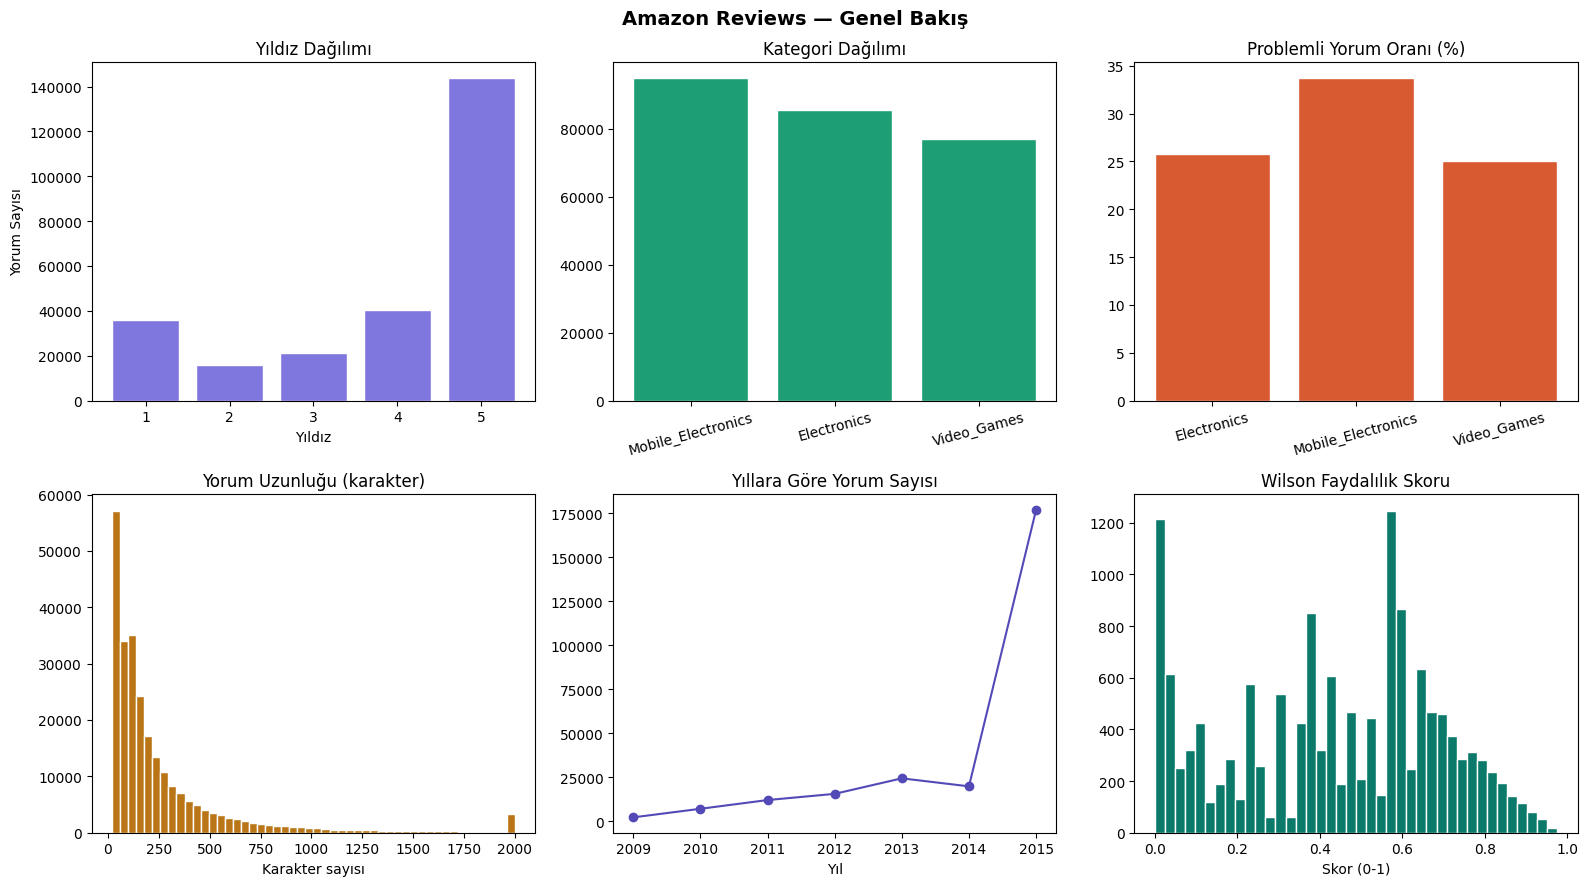

EDA grafikleri kaydedildi


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Amazon Reviews — Genel Bakış', fontsize=14, fontweight='bold')

counts = df['star_rating'].value_counts().sort_index()
axes[0,0].bar(counts.index, counts.values, color='#7F77DD', edgecolor='white')
axes[0,0].set_title('Yıldız Dağılımı')
axes[0,0].set_xlabel('Yıldız')
axes[0,0].set_ylabel('Yorum Sayısı')

src = df['kaynak'].value_counts()
axes[0,1].bar(src.index, src.values, color='#1D9E75', edgecolor='white')
axes[0,1].set_title('Kategori Dağılımı')
axes[0,1].tick_params(axis='x', rotation=15)

prob = df.groupby('kaynak')['is_problem'].mean().mul(100)
axes[0,2].bar(prob.index, prob.values, color='#D85A30', edgecolor='white')
axes[0,2].set_title('Problemli Yorum Oranı (%)')
axes[0,2].tick_params(axis='x', rotation=15)

axes[1,0].hist(df['body_len'].clip(0, 2000), bins=50, color='#BA7517', edgecolor='white')
axes[1,0].set_title('Yorum Uzunluğu (karakter)')
axes[1,0].set_xlabel('Karakter sayısı')

yillik = df.groupby('review_year').size()
axes[1,1].plot(yillik.index, yillik.values, color='#534AB7', marker='o')
axes[1,1].set_title('Yıllara Göre Yorum Sayısı')
axes[1,1].set_xlabel('Yıl')

ws = df['helpfulness_score'].dropna()
axes[1,2].hist(ws, bins=40, color='#0C7A6B', edgecolor='white')
axes[1,2].set_title('Wilson Faydalılık Skoru')
axes[1,2].set_xlabel('Skor (0-1)')

plt.tight_layout()
plt.savefig('eda_genel.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA grafikleri kaydedildi")

In [9]:
CIKTI = DRIVE_PATH + 'faz2_temiz_veri.parquet'
df.to_parquet(CIKTI, index=False, compression='snappy')

print(f"Kaydedildi: {CIKTI}")
print(f"   Boyut: {os.path.getsize(CIKTI)/1024**2:.0f} MB")
print(f"   Satır: {len(df):,}")
print(f"   Sütun: {df.shape[1]}")
print(f"\nSonraki adım → Faz3_NLP_Pipeline.ipynb")

Kaydedildi: /content/drive/MyDrive/faz2_temiz_veri.parquet
   Boyut: 63 MB
   Satır: 257,378
   Sütun: 25

Sonraki adım → Faz3_NLP_Pipeline.ipynb
